In [ ]:
import numpy as np
import os
import kagglehub
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, Flatten, SpatialDropout1D, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import shutil


In [ ]:

path = kagglehub.dataset_download("ayahkhaldi/sql-injection-dataset")
print("Path to dataset files:", path)

new_folder = '/content/sample_data/'
os.makedirs(new_folder, exist_ok=True)

datafiles = os.listdir(path)
for f in datafiles:
    src_path = os.path.join(path, f)
    dst_path = os.path.join(new_folder, f)

    if os.path.isdir(src_path):
        shutil.copytree(src_path, dst_path)
    else:
        shutil.copy2(src_path, dst_path)

Path to dataset files: /kaggle/input/sql-injection-dataset


In [ ]:
path = kagglehub.dataset_download("rtatman/glove-global-vectors-for-word-representation")
print("Path to dataset files:", path)

new_folder = '/content/sample_data/'
os.makedirs(new_folder, exist_ok=True)

datafiles = os.listdir(path)
for f in datafiles:
    src_path = os.path.join(path, f)
    dst_path = os.path.join(new_folder, f)

    if os.path.isdir(src_path):
        shutil.copytree(src_path, dst_path)
    else:
        shutil.copy2(src_path, dst_path)

Path to dataset files: /kaggle/input/glove-global-vectors-for-word-representation


In [ ]:
train_data_frame = pd.read_csv("/content/sample_data/sql-injection-datasets/Train.csv" ,lineterminator='\n')

In [ ]:
train_data_frame.head()

,Query,Label
0,The film 'Nightbreed' is one of the best horro...,0
1,The story for Hare Rama Hare Krishna actually ...,0
2,"1"" where 6347 = 6347 union all select null,nul...",1
3,jk dv1z0r39am1wjiiumia9xrxdowuo87f 110dcc d0ej...,1
4,1'|| ( select 'fdkl' where 4572 = 4572 uni...,1


In [ ]:
test_data_frame = pd.read_csv("/content/sample_data/sql-injection-datasets/Test.csv")

In [ ]:
test_data_frame.head()

,Query,Label
0,A pretentious but - to varying degrees - watch...,0.0
1,Tamar-Mattis said organization supports Austr...,0.0
2,5337,0.0
3,SELECT * FROM nothing WHERE quick NOT LIKE '[s...,0.0
4,SELECT TOP 50 PERCENT * FROM according SELECT ...,0.0


In [ ]:
validation_data_frame = pd.read_csv("/content/sample_data/sql-injection-datasets/Validation.csv")

In [ ]:
validation_data_frame.head()

,Query,Label
0,Genius or utter madness? That depends on your ...,0.0
1,Most who go to this movie will have an idea wh...,0.0
2,SELECT safe ( s ) FROM stranger,0.0
3,"SELECT Orders.knownrID, Employees.whale, Emp...",0.0
4,9999999999999999999999999999999999999999999999...,1.0


In [ ]:
print("file 1 = ",len(train_data_frame))
print("file 2 = ",len(test_data_frame))
print("file 3 = ",len(validation_data_frame))

file 1 =  98062
file 2 =  32696
file 3 =  32695


In [ ]:
train_data_frame.isna().sum()

,0
Query,0
Label,0


In [ ]:
train_data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98062 entries, 0 to 98061
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Query   98062 non-null  object
 1   Label   98062 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.5+ MB


In [ ]:
test_data_frame.isna().sum()

,0
Query,0
Label,8


In [ ]:
test_data_frame = test_data_frame.dropna()

In [ ]:
test_data_frame.isna().sum()

,0
Query,0
Label,0


In [ ]:
test_data_frame.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32688 entries, 0 to 32695
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Query   32688 non-null  object 
 1   Label   32688 non-null  float64
dtypes: float64(1), object(1)
memory usage: 766.1+ KB


In [ ]:
validation_data_frame.isna().sum()

,0
Query,0
Label,8


In [ ]:
validation_data_frame = validation_data_frame.dropna()

In [ ]:
validation_data_frame.isna().sum()

,0
Query,0
Label,0


In [ ]:
validation_data_frame.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32687 entries, 0 to 32694
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Query   32687 non-null  object 
 1   Label   32687 non-null  float64
dtypes: float64(1), object(1)
memory usage: 766.1+ KB


In [ ]:
train_data_frame[train_data_frame['Label'] == 1].count()

,0
Query,46685
Label,46685


In [ ]:
train_data_frame[train_data_frame['Label'] == 0].count()

,0
Query,51377
Label,51377


In [ ]:
test_data_frame[test_data_frame['Label'] == 1].count()

,0
Query,15494
Label,15494


In [ ]:
test_data_frame[test_data_frame['Label'] == 0].count()

,0
Query,17194
Label,17194


In [ ]:
labels = ['0', '1']
colors = ['#3242a8', '#a83242']
explode = (0.1, 0)

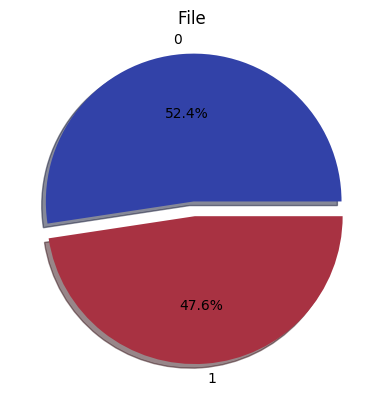

In [ ]:
sizes = train_data_frame['Label'].value_counts()
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=explode, shadow=True)
plt.title('File ')
plt.show()


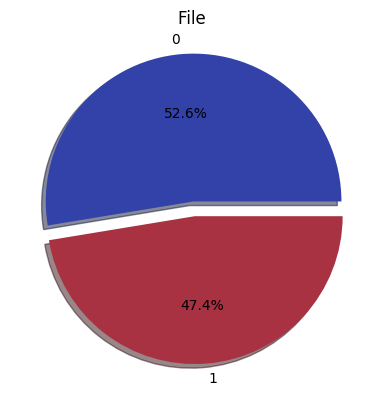

In [ ]:
sizes = test_data_frame['Label'].value_counts()
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=explode, shadow=True)
plt.title('File ')
plt.show()

In [ ]:
data_frame = pd.concat([train_data_frame, test_data_frame], ignore_index=True)

In [ ]:
data_frame.head()

,Query,Label
0,The film 'Nightbreed' is one of the best horro...,0.0
1,The story for Hare Rama Hare Krishna actually ...,0.0
2,"1"" where 6347 = 6347 union all select null,nul...",1.0
3,jk dv1z0r39am1wjiiumia9xrxdowuo87f 110dcc d0ej...,1.0
4,1'|| ( select 'fdkl' where 4572 = 4572 uni...,1.0


In [ ]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130750 entries, 0 to 130749
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Query   130750 non-null  object 
 1   Label   130750 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.0+ MB


In [ ]:
max_words = 100
max_len = 100
embedding_dim = 100
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

In [ ]:
train_query = train_data_frame['Query']
train_label = train_data_frame['Label']

test_query = test_data_frame['Query']
test_label = test_data_frame['Label']

validation_query = validation_data_frame['Query']
validation_label = validation_data_frame['Label']

In [ ]:
print(type(train_query))
print(type(train_query[0]))
print(train_query[0])

<class 'pandas.core.series.Series'>
<class 'str'>
The film 'Nightbreed' is one of the best horror films I have ever seen. Overall, I'm not a big fan of horror films, but there is something about this film that is more atmospheric and different from any other horror film I have ever seen. Many horror films i've seen i've en


In [ ]:
train_query_lower = []
for text in train_query :
  train_query_lower.append(text.lower())

tokenizer.fit_on_texts(train_query_lower)
sequences = tokenizer.texts_to_sequences(train_query_lower)
X = pad_sequences(sequences, maxlen=max_len)

In [ ]:
test_query_lower = []
for text in test_query :
  test_query_lower.append(text.lower())

tokenizer.fit_on_texts(test_query_lower)
sequences = tokenizer.texts_to_sequences(test_query_lower)
x_test = pad_sequences(sequences, maxlen=max_len)

In [ ]:
validation_query_lower = []
for text in validation_query :
  validation_query_lower.append(text.lower())

tokenizer.fit_on_texts(validation_query_lower)
sequences = tokenizer.texts_to_sequences(validation_query_lower)
X_validation = pad_sequences(sequences, maxlen=max_len)

In [ ]:
Y = np.array(train_label)
y_test = np.array(test_label)
y_validation = np.array(validation_label)

In [ ]:
embedding_index = {}
with open("/content/sample_data/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = coefs


In [ ]:

word_index = tokenizer.word_index
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    if i < max_words and word in embedding_index:
        embedding_matrix[i] = embedding_index[word]


In [ ]:
epochs = 30
batch_size = 256

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)

In [ ]:

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=True),
    SpatialDropout1D(0.2),
    Conv1D(filters=256, kernel_size=5, activation='relu'),
    BatchNormalization(),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(128, return_sequences=True)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.build(input_shape=(batch_size, max_words))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
              loss='binary_crossentropy',
              metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
    ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (256, 100, 100)        │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (256, 100, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (256, 96, 256)         │       128,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (256, 96, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (256, 92, 128)         │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (256, 46, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (256, 46, 256)         │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (256, 11776)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (256, 128)             │     1,507,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (256, 128)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (256, 1)               │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,074,001 (7.91 MB)

 Trainable params: 2,073,489 (7.91 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
checkpoint_path = "best_model.h5"
model_checkpoint = ModelCheckpoint(filepath=checkpoint_path,
    monitor='val_accuracy',save_best_only=True,
    mode='max',verbose=1)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(88255, 100)
(9807, 100)
(88255,)
(9807,)


In [ ]:
class_weights = compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train.flatten())
class_weights = dict(enumerate(class_weights))

In [ ]:
history = model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, Y_test),
    class_weight=class_weights,
    callbacks=[model_checkpoint],
    verbose=1
)

Epoch 1/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8766 - loss: 0.2816 - precision: 0.8909 - recall: 0.8478
Epoch 1: val_accuracy improved from -inf to 0.97023, saving model to best_model.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - accuracy: 0.8768 - loss: 0.2813 - precision: 0.8911 - recall: 0.8480 - val_accuracy: 0.9702 - val_loss: 0.0998 - val_precision: 0.9933 - val_recall: 0.9441
Epoch 2/30
344/345 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9711 - loss: 0.1024 - precision: 0.9864 - recall: 0.9527
Epoch 2: val_accuracy improved from 0.97023 to 0.97553, saving model to best_model.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9712 - loss: 0.1024 - precision: 0.9864 - recall: 0.9527 - val_accuracy: 0.9755 - val_loss: 0.0849 - val_precision: 0.9912 - val_recall: 0.9573
Epoch 3/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9745 - loss: 0.0884 - precision: 0.9889 - recall: 0.9569
Epoch 3: val_accuracy improved from 0.97553 to 0.97573, saving model to best_model.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9745 - loss: 0.0884 - precision: 0.9889 - recall: 0.9569 - val_accuracy: 0.9757 - val_loss: 0.0856 - val_precision: 0.9947 - val_recall: 0.9543
Epoch 4/30
344/345 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9762 - loss: 0.0837 - precision: 0.9915 - recall: 0.9582
Epoch 4: val_accuracy improved from 0.97573 to 0.97685, saving model to best_model.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9762 - loss: 0.0837 - precision: 0.9915 - recall: 0.9582 - val_accuracy: 0.9769 - val_loss: 0.0818 - val_precision: 0.9916 - val_recall: 0.9596
Epoch 5/30
344/345 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9775 - loss: 0.0777 - precision: 0.9922 - recall: 0.9601
Epoch 5: val_accuracy did not improve from 0.97685
345/345 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9775 - loss: 0.0777 - precision: 0.9922 - recall: 0.9601 - val_accuracy: 0.9759 - val_loss: 0.0829 - val_precision: 0.9914 - val_recall: 0.9579
Epoch 6/30
344/345 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9797 - loss: 0.0699 - precision: 0.9935 - recall: 0.9634
Epoch 6: val_accuracy improved from 0.97685 to 0.97859, saving model to best_model.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.9797 - loss: 0.0699 - precision: 0.9935 - recall: 0.9634 - val_accuracy: 0.9786 - val_loss: 0.0807 - val_precision: 0.9943 - val_recall: 0.9607
Epoch 7/30
344/345 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9796 - loss: 0.0673 - precision: 0.9933 - recall: 0.9636
Epoch 7: val_accuracy did not improve from 0.97859
345/345 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.9796 - loss: 0.0673 - precision: 0.9933 - recall: 0.9636 - val_accuracy: 0.9786 - val_loss: 0.0827 - val_precision: 0.9914 - val_recall: 0.9635
Epoch 8/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9805 - loss: 0.0626 - precision: 0.9940 - recall: 0.9652
Epoch 8: val_accuracy did not improve from 0.97859
345/345 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9805 - loss: 0.0626 - precision: 0.9940 - recall: 0.9652 - val_accuracy: 0.9776 - val_loss: 0.0861 - val_precision: 0.9897 - val_recall: 0.9631
Epoch 9/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms

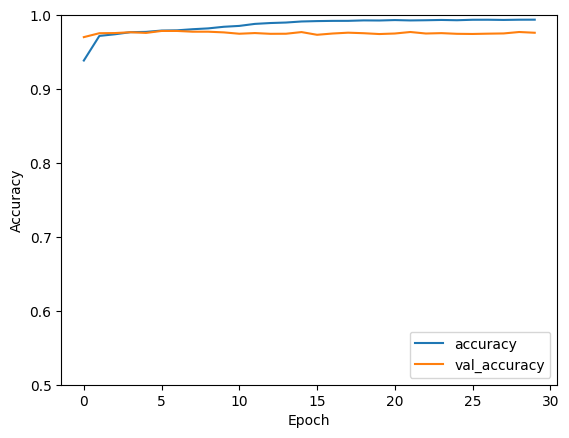

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

In [ ]:
test_metrics = model.evaluate(X, Y, return_dict=True)

3065/3065 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9929 - loss: 0.0362 - precision: 0.9974 - recall: 0.9877


In [ ]:
for name, value in test_metrics.items():
    print(f"{name}: {value*100:.4f} %")

accuracy: 99.3188 %
loss: 3.6126 %
precision: 99.7470 %
recall: 98.8198 %


In [ ]:
model.save("CNN-BLSTM_Model.h5")